# deep-sentiment-bilstm

**Author:** Sana Ur Rehman  
**Profession:** Data Scientist  
**Created:** 2026  

---

## License

This project is licensed under the **MIT License**. 

You are free to use, modify, distribute, and build upon this work for both commercial and non-commercial purposes, provided you give appropriate **credit** to the original author. For the full legal text and conditions, please refer to the `LICENSE` file included in this project's repository.

---

## Citation

If you reference or build upon this project, please provide appropriate credit.

For formal citation information, please see the project's `README.md` and `CITATION.cff` files.

# Environment Setup & GPU Verification

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

# Set visualization style for future graphs
sns.set_theme(style="whitegrid")

# Check for GPU availability 
print("TensorFlow Version:", tf.__version__)
print("-" * 30)

gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print("GPU is available and ready for training!")
    for device in gpu_devices:
        print("   ->", device)
else:
    print("No GPU found. Training LSTMs on CPU will be very slow.")
    print("   Please check your Colab runtime settings (Runtime > Change runtime type > T4 GPU).")

TensorFlow Version: 2.20.0
------------------------------
GPU is available and ready for training!
   -> PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


# Data Acquisition & Exploratory Data Analysis (EDA)

Extracting files (this might take a minute or two)...


/tmp/ipykernel_34722/1613582487.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=".")


✅ Data ready at: /content/aclImdb
Parsing text files into DataFrames...

--- Data Acquisition Complete ---
Training Set Shape: (25000, 2)
Testing Set Shape: (25000, 2)


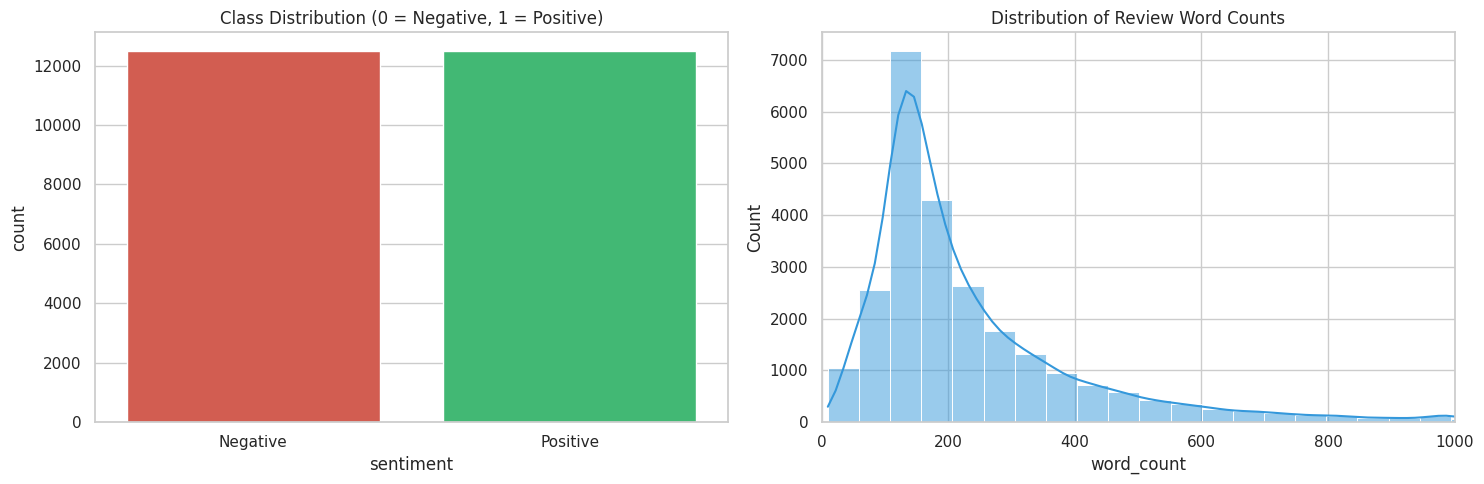


First 3 rows of the training dataset:


,review,sentiment
0,Perhaps this could be the best movie ever made...,1
1,I remember my parents not understanding Saturd...,0
2,This is a great movie for any fan of Hong Kong...,1


In [ ]:
import os
import shutil
import tarfile
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# 1. Download and Extraction
url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
file_name = "aclImdb_v1.tar.gz"
imdb_dir = "aclImdb"

if not os.path.exists(imdb_dir):
    print("Downloading the official IMDB dataset...")
    if not os.path.exists(file_name):
        urllib.request.urlretrieve(url, file_name)
    
    print("Extracting files (this might take a minute or two)...")
    with tarfile.open(file_name, 'r:gz') as tar:
        tar.extractall(path=".")
        
print(f"Data ready at: {os.path.abspath(imdb_dir)}")

# Remove the unsupervised learning folder as we only need labeled data
unv_dir = os.path.join(imdb_dir, 'train', 'unsup')
if os.path.exists(unv_dir):
    shutil.rmtree(unv_dir)

# 2. Function to load raw text files into a Pandas DataFrame
def load_data_to_df(directory):
    texts, labels = [], []
    for label_type in ['pos', 'neg']:
        dir_name = os.path.join(directory, label_type)
        if not os.path.exists(dir_name):
            print(f"Error: Could not find {dir_name}")
            return pd.DataFrame()
            
        for fname in os.listdir(dir_name):
            if fname.endswith(".txt"):
                with open(os.path.join(dir_name, fname), encoding="utf-8") as f:
                    texts.append(f.read())
                labels.append(1 if label_type == 'pos' else 0)
    
    # Create DataFrame and shuffle it
    df = pd.DataFrame({'review': texts, 'sentiment': labels})
    return df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Parsing text files into DataFrames...")
train_df = load_data_to_df(os.path.join(imdb_dir, 'train'))
test_df = load_data_to_df(os.path.join(imdb_dir, 'test'))

if not train_df.empty:
    print("\n--- Data Acquisition Complete ---")
    print(f"Training Set Shape: {train_df.shape}")
    print(f"Testing Set Shape: {test_df.shape}")

    # 3. Exploratory Data Analysis (EDA)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Plot class balance
    sns.countplot(data=train_df, x='sentiment', ax=axes[0], palette=['#e74c3c', '#2ecc71'], hue='sentiment', legend=False)
    axes[0].set_title('Class Distribution (0 = Negative, 1 = Positive)')
    axes[0].set_xticks([0, 1])
    axes[0].set_xticklabels(['Negative', 'Positive'])

    # Plot review lengths to help us decide our LSTM sequence length later
    train_df['word_count'] = train_df['review'].apply(lambda x: len(x.split()))
    sns.histplot(train_df['word_count'], bins=50, ax=axes[1], color='#3498db', kde=True)
    axes[1].set_title('Distribution of Review Word Counts')
    axes[1].set_xlim(0, 1000)

    plt.tight_layout()
    plt.show()

    # Display the first few rows of our training data
    print("\nFirst 3 rows of the training dataset:")
    display(train_df[['review', 'sentiment']].head(3))

# Text Preprocessing & Tokenization

In [8]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Hyperparameters for processing
VOCAB_SIZE = 10000  # Only keep the top 10,000 most common words in our dictionary
MAX_LENGTH = 250    # Based on your histogram, 250 words covers the vast majority of reviews
TRUNC_TYPE = 'pre' 
PAD_TYPE = 'pre'   
OOV_TOK = "<OOV>"   # "Out Of Vocabulary" token for words not in our top 10,000

# 2. Text Cleaning Function
def clean_text(text):
    # Remove HTML break tags (IMDB data is full of them)
    text = re.sub(r'<[^>]+>', ' ', text)
    # Remove special characters and numbers (keep only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert to lowercase and strip extra whitespace
    text = text.lower().strip()
    return text

print("Cleaning training and testing text...")
train_df['clean_review'] = train_df['review'].apply(clean_text)
test_df['clean_review'] = test_df['review'].apply(clean_text)

# 3. Tokenization (Building the dictionary)
print("Fitting the Tokenizer...")
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOK)
# We only fit on the training data to prevent data leakage!
tokenizer.fit_on_texts(train_df['clean_review'])

word_index = tokenizer.word_index
print(f"Found {len(word_index)} unique words in the training data.")

# 4. Sequencing and Padding
print("Converting text to padded sequences...")
train_sequences = tokenizer.texts_to_sequences(train_df['clean_review'])
train_padded = pad_sequences(train_sequences, maxlen=MAX_LENGTH, padding=PAD_TYPE, truncating=TRUNC_TYPE)

test_sequences = tokenizer.texts_to_sequences(test_df['clean_review'])
test_padded = pad_sequences(test_sequences, maxlen=MAX_LENGTH, padding=PAD_TYPE, truncating=TRUNC_TYPE)

# Convert labels to numpy arrays for TensorFlow
train_labels = np.array(train_df['sentiment'])
test_labels = np.array(test_df['sentiment'])

print("\n--- Preprocessing Complete ---")
print(f"Shape of train data tensor: {train_padded.shape}")
print(f"Shape of test data tensor: {test_padded.shape}")
print("\nExample of how a sentence looks to the LSTM (first 50 tokens of review 1):")
print(train_padded[0][:50])

Cleaning training and testing text...
Fitting the Tokenizer...
Found 109142 unique words in the training data.
Converting text to padded sequences...

--- Preprocessing Complete ---
Shape of train data tensor: (25000, 250)
Shape of test data tensor: (25000, 250)

Example of how a sentence looks to the LSTM (first 50 tokens of review 1):
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]


# Building the LSTM Architecture

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

# 1. Architecture Hyperparameters
EMBEDDING_DIM = 128
LSTM_UNITS = 64

print("Constructing the Neural Architecture...")

# 2. Building the Sequential Model
model = Sequential([
    # Embedding layer maps our 10,000-word vocabulary into 128-dimensional space
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LENGTH),
    
    # Bidirectional LSTM to understand sequence context from both directions
    Bidirectional(LSTM(LSTM_UNITS, dropout=0.2, recurrent_dropout=0.2)),
    
    # Dense head for final classification
    Dense(64, activation='relu'),
    Dropout(0.5), # 50% dropout to strictly enforce regularization
    Dense(1, activation='sigmoid') # Final output node
])

# 3. Compiling the Model
model.compile(
    loss='binary_crossentropy', 
    optimizer='adam', 
    metrics=['accuracy']
)

print("Model compiled successfully!\n")
print("--- Model Summary ---")
model.summary()

Constructing the Neural Architecture...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


✅ Model compiled successfully!

--- Model Summary ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Model Training & Callbacks

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

# 1. Re-build Architecture (Keras 3+ compliant and GPU optimized)
EMBEDDING_DIM = 128
LSTM_UNITS = 64

model = Sequential([
    Input(shape=(MAX_LENGTH,)), # Explicit input layer fixes the 'unbuilt' issue
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),
    
    # Removed recurrent_dropout so the GPU (CuDNN) can run at maximum speed
    Bidirectional(LSTM(LSTM_UNITS, dropout=0.2)),
    
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

print("--- Updated Model Summary ---")
model.summary()
print("\n" + "="*50 + "\n")

# 2. Setup Callbacks
# Stops training if validation loss doesn't improve for 2 epochs
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=2, 
    restore_best_weights=True,
    verbose=1
)

# 3. Train the Model
print("Starting Model Training! (Grab a coffee, this will take a few minutes)...")
history = model.fit(
    train_padded, train_labels,
    epochs=5,
    batch_size=128, 
    validation_split=0.2, # Use 20% of training data to test itself after every epoch
    callbacks=[early_stop]
)

print("\nTraining Complete!")

--- Updated Model Summary ---


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 250, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,387,137 (5.29 MB)

 Trainable params: 1,387,137 (5.29 MB)

 Non-trainable params: 0 (0.00 B)



Starting Model Training! (Grab a coffee, this will take a few minutes)...
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.7282 - loss: 0.5222 - val_accuracy: 0.8424 - val_loss: 0.3714
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.8823 - loss: 0.2976 - val_accuracy: 0.8650 - val_loss: 0.3523
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9231 - loss: 0.2105 - val_accuracy: 0.8654 - val_loss: 0.3292
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9409 - loss: 0.1657 - val_accuracy: 0.8696 - val_loss: 0.3683
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.9617 - loss: 0.1137 - val_accuracy: 0.8496 - val_loss: 0.5090
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 3.

Training Complete!


# Evaluation & Custom Inference

In [ ]:
# ==========================================
# Final Evaluation on Unseen Data
# ==========================================
print("Grading the model on the 25,000 unseen test reviews...")
test_loss, test_acc = model.evaluate(test_padded, test_labels, verbose=1)
print(f"Final Test Accuracy: {test_acc * 100:.2f}%\n")
print("=" * 50 + "\n")

# ==========================================
# Custom Inference Pipeline
# ==========================================
def predict_sentiment(review_text):
    """Takes a raw string, preprocesses it, and predicts the sentiment."""
    # 1. Clean the text using our previous function
    cleaned = clean_text(review_text)
    
    # 2. Tokenize and pad the sequence
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(sequence, maxlen=MAX_LENGTH, padding=PAD_TYPE, truncating=TRUNC_TYPE)
    
    # 3. Feed it to the LSTM
    prediction = model.predict(padded, verbose=0)[0][0]
    
    # 4. Format the output based on a 0.5 threshold
    sentiment = "Positive 🟢" if prediction >= 0.5 else "Negative 🔴"
    # Calculate confidence percentage
    confidence = prediction if prediction >= 0.5 else 1 - prediction
    
    print(f"Review: '{review_text}'")
    print(f"Sentiment: {sentiment}")
    print(f"Confidence: {confidence * 100:.2f}%\n")
    print("-" * 40)

# Let's test the engine!
print("Testing the custom inference pipeline...\n")

# Test 1: Clear Positive
predict_sentiment("This movie was an absolute masterpiece! The acting was phenomenal and the plot was gripping from start to finish.")

# Test 2: Clear Negative
predict_sentiment("Honestly, it was a massive waste of time. The script was terrible and I fell asleep halfway through.")

# Test 3: Sarcastic/Mixed
predict_sentiment("I would rather watch paint dry than sit through another sequel of this garbage.")

Grading the model on the 25,000 unseen test reviews...
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8487 - loss: 0.3620
Final Test Accuracy: 84.87%


Testing the custom inference pipeline...

Review: 'This movie was an absolute masterpiece! The acting was phenomenal and the plot was gripping from start to finish.'
Sentiment: Positive 🟢
Confidence: 82.63%

----------------------------------------
Review: 'Honestly, it was a massive waste of time. The script was terrible and I fell asleep halfway through.'
Sentiment: Negative 🔴
Confidence: 99.94%

----------------------------------------
Review: 'I would rather watch paint dry than sit through another sequel of this garbage.'
Sentiment: Negative 🔴
Confidence: 98.22%

----------------------------------------
